# Netflix Movies and TV Shows — Data Analysis

## Project Overview
This project analyzes the Netflix Movies and TV Shows dataset using Python, Pandas, NumPy, and Matplotlib to identify patterns in content types, release trends, ratings, and genres.

## Objectives
- Load and inspect a real-world CSV dataset.
- Clean missing values and duplicate records.
- Perform exploratory data analysis (EDA).
- Create at least four visualizations.
- Identify 5–8 insights supported by actual results.

## Tools Used
Python, Pandas, NumPy, Matplotlib, Seaborn and Jupyter Notebook.

## Dataset Source
https://www.kaggle.com/datasets/shivamb/netflix-shows

## 1. Loading and Sampling the Dataset

The original Netflix dataset contains thousands of records (~8800). To make the analysis more manageable, a reproducible random sample of 2,000 records will be selected.

Using a fixed random seed ensures that the same sample can be generated each time the code is executed. The original dataset will remain unchanged, and the selected sample will be used for the subsequent analysis.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load the original dataset
df_original = pd.read_csv("../data/netflix_titles.csv")

print("Original dataset shape:", df_original.shape)

# Select a reproducible random sample of 2,000 rows
df = df_original.sample(n=2000, random_state=86).reset_index(drop=True)

# Save the sampled dataset
df.to_csv("../data/netflix_sample.csv", index=False)

print("Sampled dataset shape:", df.shape)
print("Sample saved successfully!")

# Apply a clean chart style
sns.set_theme(style="whitegrid")

Original dataset shape: (8807, 12)
Sampled dataset shape: (2000, 12)
Sample saved successfully!


## 2. Initial Dataset Inspection

The sampled dataset is inspected to understand its structure, available columns, data types, and missing values before cleaning begins.

In [26]:
# Display the first five records
display(df.head())

# Inspect the dataset structure
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display column names, data types, and non-null counts
df.info()

# Count missing values in each column
print("\nMissing values per column:")
print(df.isnull().sum())

# Check duplicate records
print("\nDuplicate rows:", df.duplicated().sum())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s3352,TV Show,Vientos de agua,NaN,"Ernesto Alterio, Eduardo Blanco, Héctor Alteri...","Argentina, Spain","November 1, 2019",2006,TV-MA,1 Season,"International TV Shows, Spanish-Language TV Sh...","José Olaya, a Spanish miner, emigrates to Arge..."
1,s557,Movie,The 8th Night,Kim Tae-hyung,"Lee Sung-min, Park Hae-joon, Kim You-jung, Nam...",South Korea,"July 2, 2021",2021,TV-14,116 min,"Horror Movies, International Movies, Thrillers",With prayer beads in one hand and an ax in the...
2,s1855,TV Show,Social Distance,NaN,"Danielle Brooks, Oscar Nuñez, Mike Colter, Hea...",United States,"October 15, 2020",2020,TV-MA,1 Season,"TV Comedies, TV Dramas","Filmed in isolation, this narrative anthology ..."
3,s2925,Movie,French Toast,"Paul Krüger, Anél Stolp","Lika Berning, Thierry Ballarin, Deon Lotz, Hel...",South Africa,"February 12, 2020",2015,TV-PG,86 min,"Comedies, International Movies, Romantic Movies",With only her mother's diary and a locket as c...
4,s8495,Movie,THE RUM DIARY,Bruce Robinson,"Johnny Depp, Aaron Eckhart, Michael Rispoli, A...","United States, United Kingdom","December 6, 2019",2011,R,120 min,"Comedies, Dramas",Johnny Depp stars in this adaptation of Hunter...


Number of rows: 2000
Number of columns: 12
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       2000 non-null   str  
 1   type          2000 non-null   str  
 2   title         2000 non-null   str  
 3   director      1377 non-null   str  
 4   cast          1783 non-null   str  
 5   country       1802 non-null   str  
 6   date_added    1997 non-null   str  
 7   release_year  2000 non-null   int64
 8   rating        1998 non-null   str  
 9   duration      2000 non-null   str  
 10  listed_in     2000 non-null   str  
 11  description   2000 non-null   str  
dtypes: int64(1), str(11)
memory usage: 187.6 KB

Missing values per column:
show_id           0
type              0
title             0
director        623
cast            217
country         198
date_added        3
release_year      0
rating            2
duration          0
listed_in 

## 3. Data Cleaning

Data cleaning improves dataset quality before analysis. This stage checks for duplicate records and missing values.

Exact duplicate rows are removed using `drop_duplicates()`. Missing values in the `director`, `cast`, and `country` columns are replaced with `"Unknown"` to preserve the records while indicating unavailable information.

Rows with missing values in `rating` or `date_added` are removed using `dropna(subset=["rating", "date_added"])`. This ensures that the cleaned dataset contains valid values in these two columns. The original sampled dataset is preserved in `df`, while the cleaned dataset is stored in `df_clean`.

In [27]:
# Create a separate copy for cleaning
df_clean = df.copy()

# Record the initial dataset size
initial_rows = len(df_clean)

# Check exact duplicate rows
duplicate_count = df_clean.duplicated().sum()
print("Duplicate rows found:", duplicate_count)

# Remove exact duplicate rows
df_clean = df_clean.drop_duplicates()

# Display the result
print("Rows before removing duplicates:", initial_rows)
print("Rows after removing duplicates:", len(df_clean))
print("Duplicate rows remaining:", df_clean.duplicated().sum())

# Check missing values after duplicate removal
print("\nMissing values per column:")
print(df_clean.isnull().sum())

Duplicate rows found: 0
Rows before removing duplicates: 2000
Rows after removing duplicates: 2000
Duplicate rows remaining: 0

Missing values per column:
show_id           0
type              0
title             0
director        623
cast            217
country         198
date_added        3
release_year      0
rating            2
duration          0
listed_in         0
description       0
dtype: int64


### 3.1 Handling Missing Values

Missing values must be handled according to the purpose of each column. In this dataset, missing director, cast, and country information is replaced with `"Unknown"` because these details cannot be reliably inferred from the available data.

Rows with missing `rating` or `date_added` values are removed because these fields are required for the corresponding analysis. The missing-value counts are checked before and after cleaning to verify the results.

In [28]:

# Fill missing categorical information with "Unknown"
categorical_columns = ["director", "cast", "country"]

for column in categorical_columns:
    df_clean[column] = df_clean[column].fillna("Unknown")


# Check missing rating and date_added values before removal
print("Missing values before removing rows:")
print(df_clean[["rating", "date_added"]].isnull().sum())


# Remove rows with missing rating or date_added
df_clean = df_clean.dropna(subset=["rating", "date_added"])


# Check missing values after cleaning
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())


# Check the cleaned dataset dimensions
print("\nCleaned dataset shape:", df_clean.shape)


# Save the cleaned dataset
df_clean.to_csv("../data/netflix_cleaned.csv", index=False)

print("\nCleaned dataset saved successfully!")

Missing values before removing rows:
rating        2
date_added    3
dtype: int64

Missing values after cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

Cleaned dataset shape: (1995, 12)

Cleaned dataset saved successfully!


### 3.2 Cleaning Summary

The cleaned dataset is checked to verify that duplicate rows have been removed and the selected missing-value treatments have been applied.

Missing values in `director`, `cast`, and `country` are replaced with `"Unknown"`. Rows with missing `rating` or `date_added` values are dropped. The final dataset shape and missing-value counts are displayed to confirm the cleaning results.


In [29]:
print("Final number of rows:", len(df_clean))
print("Final number of columns:", len(df_clean.columns))
print("Duplicate rows remaining:", df_clean.duplicated().sum())

print("\nRemaining missing values:")
print(df_clean.isnull().sum())

print("\nPreview of cleaned dataset:")
display(df_clean.head())

Final number of rows: 1995
Final number of columns: 12
Duplicate rows remaining: 0

Remaining missing values:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

Preview of cleaned dataset:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s3352,TV Show,Vientos de agua,Unknown,"Ernesto Alterio, Eduardo Blanco, Héctor Alteri...","Argentina, Spain","November 1, 2019",2006,TV-MA,1 Season,"International TV Shows, Spanish-Language TV Sh...","José Olaya, a Spanish miner, emigrates to Arge..."
1,s557,Movie,The 8th Night,Kim Tae-hyung,"Lee Sung-min, Park Hae-joon, Kim You-jung, Nam...",South Korea,"July 2, 2021",2021,TV-14,116 min,"Horror Movies, International Movies, Thrillers",With prayer beads in one hand and an ax in the...
2,s1855,TV Show,Social Distance,Unknown,"Danielle Brooks, Oscar Nuñez, Mike Colter, Hea...",United States,"October 15, 2020",2020,TV-MA,1 Season,"TV Comedies, TV Dramas","Filmed in isolation, this narrative anthology ..."
3,s2925,Movie,French Toast,"Paul Krüger, Anél Stolp","Lika Berning, Thierry Ballarin, Deon Lotz, Hel...",South Africa,"February 12, 2020",2015,TV-PG,86 min,"Comedies, International Movies, Romantic Movies",With only her mother's diary and a locket as c...
4,s8495,Movie,THE RUM DIARY,Bruce Robinson,"Johnny Depp, Aaron Eckhart, Michael Rispoli, A...","United States, United Kingdom","December 6, 2019",2011,R,120 min,"Comedies, Dramas",Johnny Depp stars in this adaptation of Hunter...


## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) involves examining a dataset to understand its structure, distributions, and patterns before drawing conclusions. Pandas and NumPy help summarize and analyze data efficiently.

In this section, the cleaned Netflix dataset will be explored to answer questions such as:

* How many movies and TV shows are present?
* Which years have the most released titles?
* Which content ratings appear most frequently?
* Which countries contribute the most titles?

The findings will guide the creation of visualizations and help identify meaningful insights from the sampled dataset.


In [30]:
# Display basic information about the cleaned dataset
print("Dataset shape:", df_clean.shape)

print("\nColumn data types and non-null counts:")
df_clean.info()

print("\nNumerical summary:")
display(df_clean.describe())

print("\nNumber of unique values in each column:")
print(df_clean.nunique())

print("\nNumber of titles by content type:")
print(df_clean["type"].value_counts())

Dataset shape: (1995, 12)

Column data types and non-null counts:
<class 'pandas.DataFrame'>
Index: 1995 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       1995 non-null   str  
 1   type          1995 non-null   str  
 2   title         1995 non-null   str  
 3   director      1995 non-null   str  
 4   cast          1995 non-null   str  
 5   country       1995 non-null   str  
 6   date_added    1995 non-null   str  
 7   release_year  1995 non-null   int64
 8   rating        1995 non-null   str  
 9   duration      1995 non-null   str  
 10  listed_in     1995 non-null   str  
 11  description   1995 non-null   str  
dtypes: int64(1), str(11)
memory usage: 202.6 KB

Numerical summary:


,release_year
count,1995.000000
mean,2014.454135
std,8.401609
min,1925.000000
25%,2014.000000
50%,2017.000000
75%,2019.000000
max,2021.000000



Number of unique values in each column:
show_id         1995
type               2
title           1995
director        1231
cast            1754
country          262
date_added       946
release_year      57
rating            13
duration         165
listed_in        306
description     1991
dtype: int64

Number of titles by content type:
type
Movie      1363
TV Show     632
Name: count, dtype: int64


## 5. Data Visualization

Data visualization presents information in graphical form, making patterns and comparisons easier to understand. Matplotlib will be used to create charts from the cleaned Netflix dataset.

### 5.1 Movies vs. TV Shows

A bar chart will compare the number of Movies and TV Shows in the sample. The chart will help show which content type is more common in the selected records.


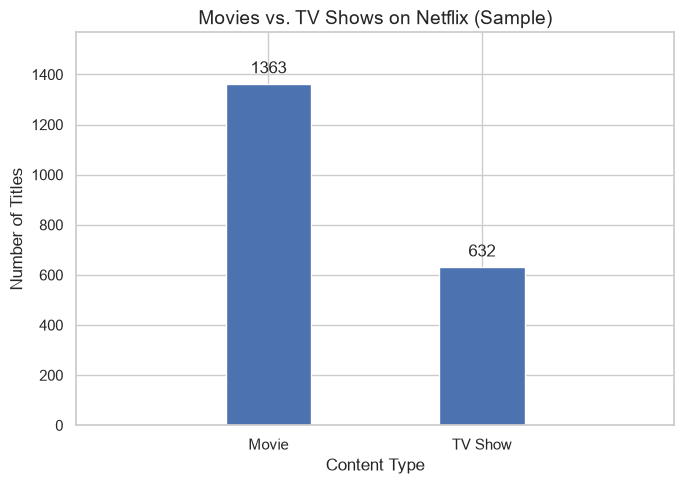

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Count each content type
type_counts = df_clean["type"].value_counts()

# Create custom positions closer together
positions = np.array([-0.25, 0.25])

plt.figure(figsize=(7, 5))

bars = plt.bar(
    positions,
    type_counts.values,
    width=0.2
)

# Add count labels
plt.bar_label(bars, padding=5)

plt.xticks(positions, type_counts.index)
plt.title("Movies vs. TV Shows on Netflix (Sample)", fontsize=14)
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.ylim(0, type_counts.max() * 1.15)
plt.xlim(-0.7, 0.7)
plt.tight_layout()
plt.show()

### 5.2 Netflix Titles Added by Year

A line chart displays changes in values over time and helps identify trends across different periods. In this analysis, the `date_added` column will be converted into a datetime format, and titles will be grouped by the year they were added to Netflix.

The chart will help identify years in which more or fewer titles were added within the sampled dataset. Records with missing or invalid `date_added` values will be excluded from this particular analysis because their addition year cannot be determined.


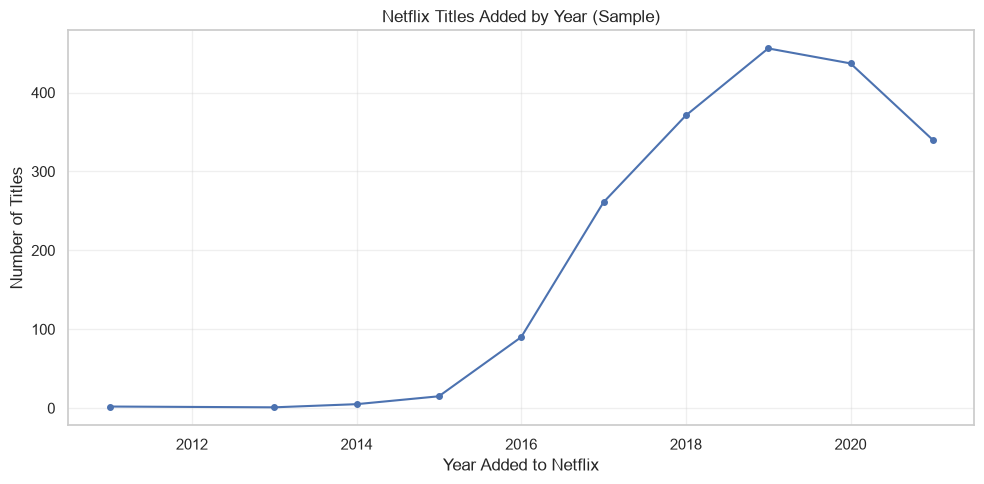

In [32]:
# Convert date_added to datetime
df_clean["date_added_parsed"] = pd.to_datetime(
    df_clean["date_added"],
    errors="coerce"
)

# Count titles added each year
added_year_counts = (
    df_clean["date_added_parsed"]
    .dropna()
    .dt.year
    .value_counts()
    .sort_index()
)

# Create the line chart
plt.figure(figsize=(10, 5))
plt.plot(
    added_year_counts.index,
    added_year_counts.values,
    marker="o",
    markersize=4
)

plt.title("Netflix Titles Added by Year (Sample)")
plt.xlabel("Year Added to Netflix")
plt.ylabel("Number of Titles")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3 Distribution of Movie Durations

A histogram displays the distribution of numerical data by grouping values into intervals called bins. In this analysis, movie durations will be extracted from the `duration` column and converted into numeric values. The histogram will help identify the most common duration ranges and show how movie lengths vary within the sampled Netflix dataset.

Only movies with valid durations measured in minutes will be included. TV Shows are excluded because their durations are recorded in seasons rather than minutes.


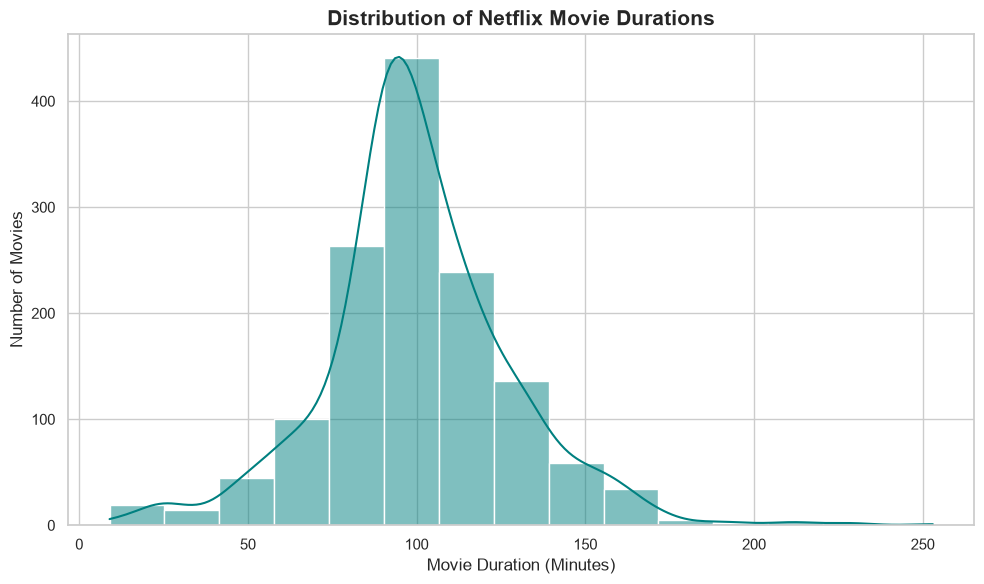

In [33]:
# Select movies with valid durations in minutes
movie_durations = (
    df_clean.loc[
        (df_clean["type"] == "Movie") &
        (df_clean["duration"].str.contains("min", na=False)),
        "duration"
    ]
    .str.replace(" min", "", regex=False)
    .astype(int)
)

# Apply a clean visualization style
sns.set_theme(style="whitegrid")

# Create the histogram
plt.figure(figsize=(10, 6))

sns.histplot(
    data=movie_durations,
    bins=15,
    kde=True,
    color="teal",
    edgecolor="white",
    linewidth=1
)

plt.title(
    "Distribution of Netflix Movie Durations",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Movie Duration (Minutes)")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

### 5.4 Distribution of Titles by Release Year

A pie chart represents categories as proportions of a whole. This chart will show how the sampled Netflix titles are distributed across release years. To keep the chart readable, the ten release years with the highest title counts will be displayed individually, while the remaining years will be combined into an “Other years” category.


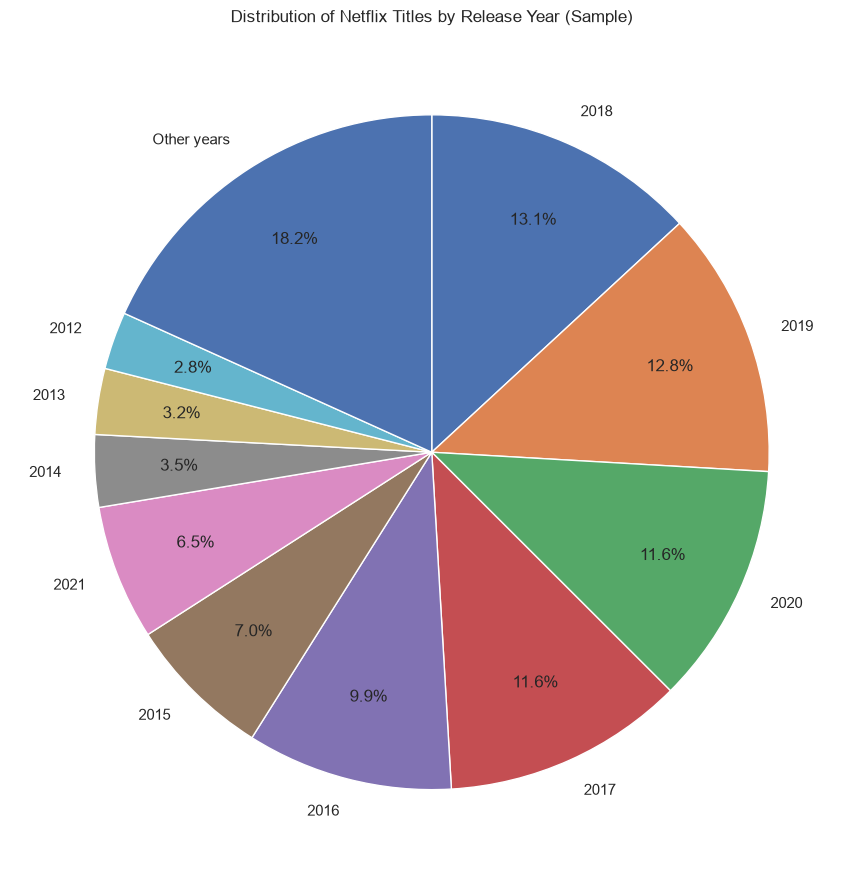

In [34]:
# Count titles by release year
year_counts = df_clean["release_year"].value_counts().sort_values(
    ascending=False
)

# Select the 10 most frequent release years
top_10_years = year_counts.head(10)

# Group all remaining years into one category
other_years_count = year_counts.iloc[10:].sum()

pie_data = top_10_years.copy()

if other_years_count > 0:
    pie_data.loc["Other years"] = other_years_count

# Create the pie chart
plt.figure(figsize=(9, 9))

plt.pie(
    pie_data.values,
    labels=pie_data.index,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    pctdistance=0.75
)

plt.title("Distribution of Netflix Titles by Release Year (Sample)")
plt.tight_layout()
plt.show()

### 5.5 Relationship Between Movie Release Year and Duration

A scatter plot displays the relationship between two numerical variables. In this analysis, the movie's release year will be plotted against its duration in minutes. Each point represents one movie with a valid duration.

The visualization can help reveal patterns in movie durations across different release years, although it does not establish a causal relationship between the two variables.


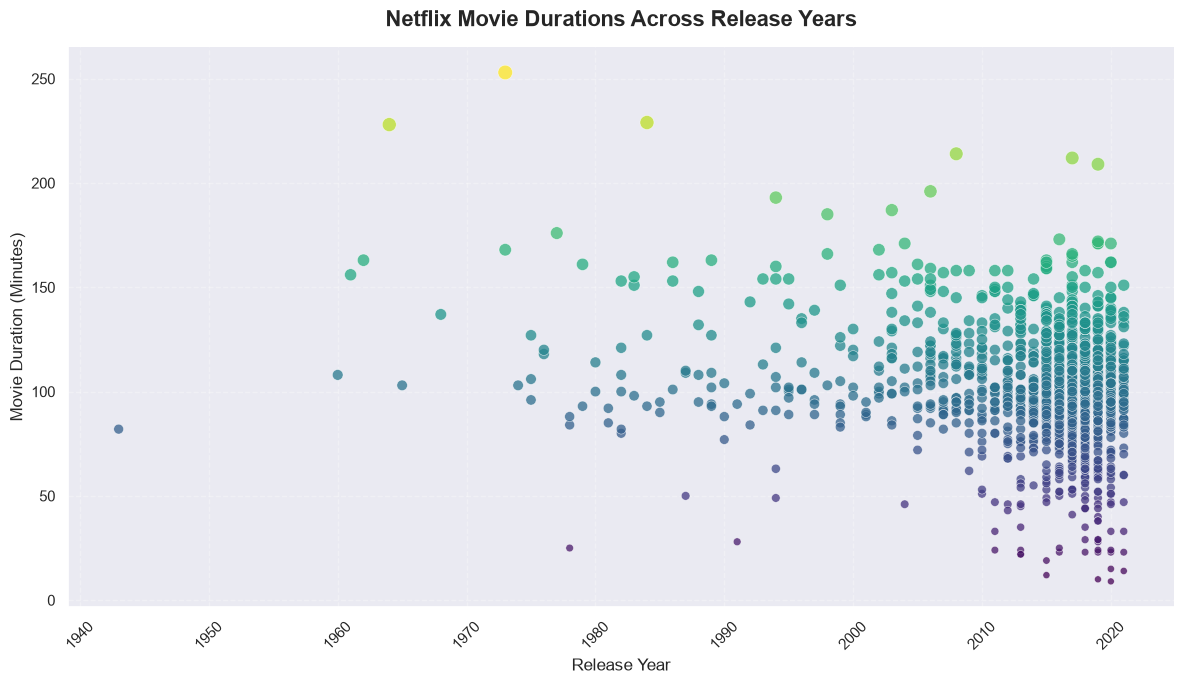

In [35]:
# Select movies with durations recorded in minutes
movie_data = df_clean[
    (df_clean["type"] == "Movie") &
    (df_clean["duration"].str.contains("min", na=False))
].copy()

# Extract numeric duration in minutes
movie_data["duration_minutes"] = (
    movie_data["duration"]
    .str.replace(" min", "", regex=False)
    .astype(int)
)

# Set the chart style
sns.set_theme(style="darkgrid", context="notebook")

# Create the scatter plot
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=movie_data,
    x="release_year",
    y="duration_minutes",
    hue="duration_minutes",
    palette="viridis",
    size="duration_minutes",
    sizes=(25, 110),
    alpha=0.75,
    edgecolor="white",
    linewidth=0.4,
    legend=False
)

# Improve titles and labels
plt.title(
    "Netflix Movie Durations Across Release Years",
    fontsize=16,
    fontweight="bold",
    pad=15
)
plt.xlabel("Release Year", fontsize=12)
plt.ylabel("Movie Duration (Minutes)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

## 6. Key Insights from the Data

This section summarizes patterns identified through exploratory data analysis and visualization. The insights are based on the 2,000 sampled Netflix records and should not be interpreted as exact statistics for the entire Netflix catalogue.


In [36]:
# 1. Movies vs. TV Shows
print("Content type counts:")
print(df_clean["type"].value_counts())

# 2. Top 5 release years
print("\nTop 5 release years:")
print(df_clean["release_year"].value_counts().head(5))

# 3. Top 5 content ratings
print("\nTop 5 content ratings:")
print(df_clean["rating"].value_counts().head(5))

# 4. Top 5 countries (split multiple-country entries)
country_counts = (
    df_clean.loc[df_clean["country"] != "Unknown", "country"]
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)

print("\nTop 5 countries:")
print(country_counts.head(5))

# 5. Movie duration summary
movie_data = df_clean[
    (df_clean["type"] == "Movie") &
    (df_clean["duration"].str.contains("min", na=False))
].copy()

movie_data["duration_minutes"] = (
    movie_data["duration"]
    .str.replace(" min", "", regex=False)
    .astype(int)
)

print("\nMovie duration summary:")
print(movie_data["duration_minutes"].describe().round(2))

# 6. Titles added by year
print("\nTop 5 years by titles added to Netflix:")
print(
    df_clean["date_added_parsed"]
    .dropna()
    .dt.year
    .value_counts()
    .head(5)
)

Content type counts:
type
Movie      1363
TV Show     632
Name: count, dtype: int64

Top 5 release years:
release_year
2018    262
2019    255
2020    231
2017    231
2016    197
Name: count, dtype: int64

Top 5 content ratings:
rating
TV-MA    689
TV-14    531
TV-PG    215
R        180
PG-13     91
Name: count, dtype: int64

Top 5 countries:
country
United States     826
India             247
United Kingdom    205
Canada            104
France             87
Name: count, dtype: int64

Movie duration summary:
count    1363.00
mean      100.32
std        28.09
min         9.00
25%        87.00
50%        98.00
75%       115.00
max       253.00
Name: duration_minutes, dtype: float64

Top 5 years by titles added to Netflix:
date_added_parsed
2019    456
2020    437
2018    371
2021    340
2017    261
Name: count, dtype: int64


### 6.1 Movies Are More Common Than TV Shows

The cleaned sample contains 1,363 movies and 632 TV Shows. Movies account for approximately 68.3% of the cleaned records, while TV Shows account for 31.7%. This indicates that movies are the more common content type in this sample.

### 6.2 Recent Release Years Have High Representation

The year 2018 has the highest number of sampled titles, with 262 records, followed by 2019 with 255. The years 2020 and 2017 each have 231 titles, while 2016 has 197. These years are strongly represented in the cleaned sample.

### 6.3 TV-MA Is the Most Common Content Rating

TV-MA appears 689 times, followed by TV-14 with 531 and TV-PG with 215. The R and PG-13 ratings appear 180 and 91 times, respectively. TV-MA is the most frequent rating among the cleaned sampled records.

### 6.4 The United States Has the Highest Country Count

The United States appears 826 times in the country analysis, followed by India with 247 and the United Kingdom with 205. Canada and France follow with 104 and 87 entries. Since some titles list multiple countries, these figures represent country-title entries rather than necessarily unique titles.

### 6.5 Movie Durations Cluster Around Feature-Length Running Times

The average movie duration is approximately 100.32 minutes, while the median is 98 minutes. The middle 50% of movie durations fall between 87 and 115 minutes. This indicates that the central portion of the sampled movie durations is concentrated within this range.

### 6.6 Some Movies Have Much Longer or Shorter Durations

The shortest recorded movie duration is 9 minutes, while the longest is 253 minutes. The standard deviation is approximately 28.09 minutes, indicating variation in movie lengths. These extreme values may represent short-form content or unusually long movies and can be investigated further if needed.

### 6.7 The Year 2019 Has the Highest Count of Titles Added

The sample contains 456 titles added to Netflix in 2019, followed by 437 in 2020 and 371 in 2018. The years 2021 and 2017 follow with 340 and 261 titles, respectively. These counts describe when titles were added to the platform, not when they were originally released.

### 6.8 Release Year and Addition Year Describe Different Events

The release-year analysis identifies 2018 as the most frequent release year in the cleaned sample, while the addition-year analysis identifies 2019 as the year with the highest number of titles added to Netflix. This distinction demonstrates why `release_year` and `date_added` should be analyzed separately.


## 7. Conclusion

This project used Python to analyze a 2,000-record sample of the Netflix Movies and TV Shows dataset. The workflow included dataset inspection, duplicate checking, handling missing categorical values, exploratory data analysis, and five types of visualizations: bar chart, line chart, histogram, pie chart, and scatter plot.

The analysis identified differences between Movies and TV Shows, common release years and content ratings, country representation, movie-duration patterns, and trends in the years titles were added to Netflix. The project also demonstrates the importance of distinguishing missing information from actual values and interpreting sample results within their limitations.

These techniques provide a foundation for more advanced data analysis and help present dataset findings in a clear, structured, and reproducible manner.
